In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("../paysim.csv", low_memory=False)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
df.info()

Rows : 6362620
Columns : 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate Rows : 0
isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


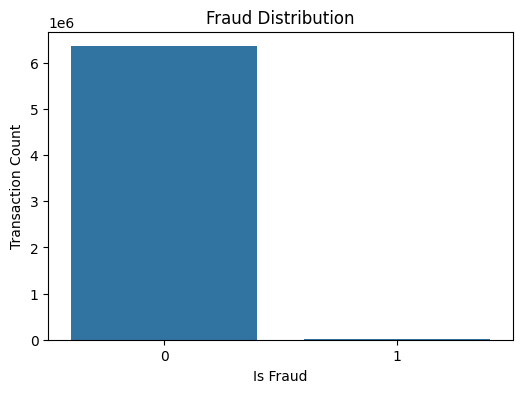

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)
df.describe().T
fraud = df["isFraud"].value_counts()

print(fraud)
fraud_percentage = (
    df["isFraud"]
    .value_counts(normalize=True)
    * 100
)

print(fraud_percentage)
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="isFraud")

plt.title("Fraud Distribution")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Count")

plt.show()

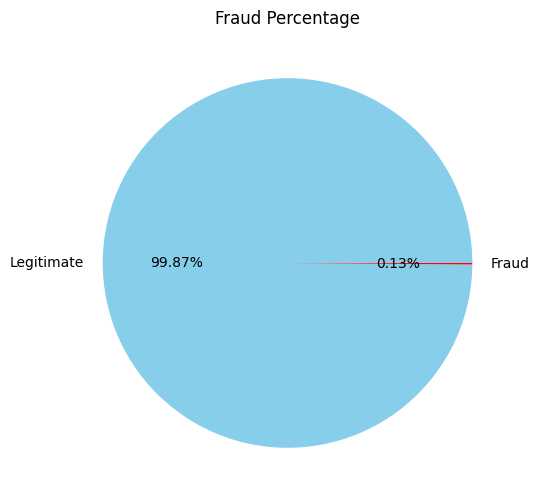

In [7]:
plt.figure(figsize=(6,6))

df["isFraud"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    labels=["Legitimate", "Fraud"],
    colors=["skyblue", "red"]
)

plt.title("Fraud Percentage")

plt.ylabel("")

plt.show()

In [8]:
df["type"].value_counts()
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [9]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
      .mean()
      .sort_values(ascending=False) * 100
)

fraud_by_type
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [10]:
df["isFraud"].value_counts(normalize=True) * 100
data = df.drop(
    columns=[
        "step",
        "nameOrig",
        "nameDest",
        "isFlaggedFraud"
    ]
)

data.head()
data = pd.get_dummies(
    data,
    columns=["type"],
    drop_first=True,
    dtype=int
)

data.head()
X = data.drop("isFraud", axis=1)

y = data["isFraud"]

print(X.shape)
print(y.shape)

(6362620, 9)
(6362620,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (4771965, 9)
Testing Shape : (1590655, 9)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))
print("X_train :", X_train_scaled.shape)
print("X_test  :", X_test_scaled.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (4771965, 9)
X_test  : (1590655, 9)
y_train : (4771965,)
y_test  : (1590655,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9996403997095537
Precision: 0.9501519756838905
Recall   : 0.7613248904042864
F1 Score : 0.8453217955651704
ROC AUC  : 0.9945962019353783

Confusion Matrix
[[1588520      82]
 [    490    1563]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.95      0.76      0.85      2053

    accuracy                           1.00   1590655
   macro avg       0.97      0.88      0.92   1590655
weighted avg       1.00      1.00      1.00   1590655



In [23]:
import pickle

pickle.dump(xgb_model, open("XGBoostModel.pkl", "wb"))

In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0.2,

    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9996492011152638
Precision: 0.9710144927536232
Recall   : 0.7506088650754993
F1 Score : 0.8467032967032967
ROC AUC  : 0.9997557648485442

Confusion Matrix
[[1588556      46]
 [    512    1541]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.97      0.75      0.85      2053

    accuracy                           1.00   1590655
   macro avg       0.99      0.88      0.92   1590655
weighted avg       1.00      1.00      1.00   1590655



In [26]:
for threshold in [0.50, 0.45, 0.40, 0.35]:
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))


Threshold: 0.5
Precision: 0.9710144927536232
Recall   : 0.7506088650754993
F1 Score : 0.8467032967032967

Threshold: 0.45
Precision: 0.9652389819987586
Recall   : 0.7574281539210911
F1 Score : 0.8487991266375546

Threshold: 0.4
Precision: 0.9578239608801956
Recall   : 0.763273258645884
F1 Score : 0.8495527243155326

Threshold: 0.35
Precision: 0.9353701527614571
Recall   : 0.7754505601558694
F1 Score : 0.8479360852197071


In [27]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

773.6696428571429


In [28]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.50).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9967623400423096
Precision: 0.2843615095390614
Recall   : 0.9946419873356064
F1 Score : 0.4422785358457873
ROC AUC  : 0.9996217535305221
[[1583463    5139]
 [     11    2042]]


In [32]:
y_pred = (y_prob >= 0.40).astype(int)

print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Precision: 0.24367541766109785
Recall   : 0.9946419873356064
F1 Score : 0.3914502060768715
[[1582264    6338]
 [     11    2042]]


In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [35]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9996561165054647
Precision: 0.9777918781725888
Recall   : 0.7506088650754993
F1 Score : 0.8492697712868559
ROC AUC  : 0.9995705123442781

Confusion Matrix
[[1588567      35]
 [    512    1541]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.98      0.75      0.85      2053

    accuracy                           1.00   1590655
   macro avg       0.99      0.88      0.92   1590655
weighted avg       1.00      1.00      1.00   1590655



In [37]:
import pickle

# Save the Random Forest model
with open("RandomForestModel.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [38]:
# Load the saved model
with open("RandomForestModel.pkl", "rb") as file:
    loaded_rf_model = pickle.load(file)

print(loaded_rf_model)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)


In [39]:
import pickle

with open("XGBoostModel.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [40]:
import pickle

xgb_model = pickle.load(open("XGBoostModel.pkl", "rb"))

In [41]:
print(X.columns)

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='object')


In [43]:
import pickle

xgb_model = pickle.load(open("XGBoostModel.pkl", "rb"))